# M1.Ex2: Model Experience vs Salary

### Name: Shaima Alqahtani

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [19]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [20]:
df = pd.read_csv("../../../datasets/Salary Data.csv")
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [21]:
X = df[["Experience Years"]]
y = df["Salary"]

### Step 2.b print the type of each

In [22]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [23]:
print("Target type: numerical")
print("Task type: regression")

Target type: numerical
Task type: regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [24]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (40, 1)
y shape: (40,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [25]:
df.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


### Step 5. Plot the feature vs the target

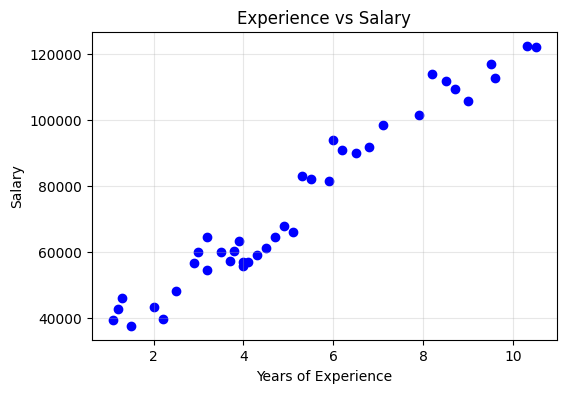

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df["Experience Years"], df["Salary"], color="blue")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.grid(True, alpha=0.3)
plt.show()


### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [30]:
print("Relationship: increasing (positive correlation)")

Relationship: increasing (positive correlation)


### Step 7. Initialize a regression model

In [32]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Step 9.a Train the model on the training set

In [35]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [36]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope: {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"Model equation: y = {slope:.3f} * x + {intercept:.3f}")

Slope: 9408.031
Intercept: 26716.250
Model equation: y = 9408.031 * x + 26716.250


### Step 9.c how much salary does a person get with 2 years of experience?

In [37]:
salary_2yrs = model.predict([[2]])[0]
print(f"Predicted salary for 2 years experience: {salary_2yrs:.2f}")

Predicted salary for 2 years experience: 45532.31


c:\Users\Dell\OneDrive\سطح المكتب\B5\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [38]:
increase_6months = slope * 0.5
print(f"Salary increase for 6 months experience: {increase_6months:.2f}")

Salary increase for 6 months experience: 4704.02


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [39]:
print(f"Salary for 0 experience: {intercept:.2f}")

Salary for 0 experience: 26716.25


### Step 10. Evaluate the model on the test set

In [41]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_test = model.predict(X_test)

r2 = r2_score(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = mse ** 0.5

print("R^2:", r2)
print("MSE:", mse)
print("RMSE:", rmse)


R^2: 0.9068577573647874
MSE: 48077731.16919359
RMSE: 6933.810724932834


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [42]:
sample_X = X_test.head(3)
sample_y_true = y_test.head(3)
sample_y_pred = model.predict(sample_X)

for i in range(3):
    print(f"Experience: {sample_X.iloc[i,0]}, True Salary: {sample_y_true.iloc[i]}, Predicted: {sample_y_pred[i]:.2f}")

Experience: 4.5, True Salary: 61111, Predicted: 69052.39
Experience: 4.0, True Salary: 56957, Predicted: 64348.38
Experience: 4.0, True Salary: 55794, Predicted: 64348.38


### Step 12. Plot the data and the regression line

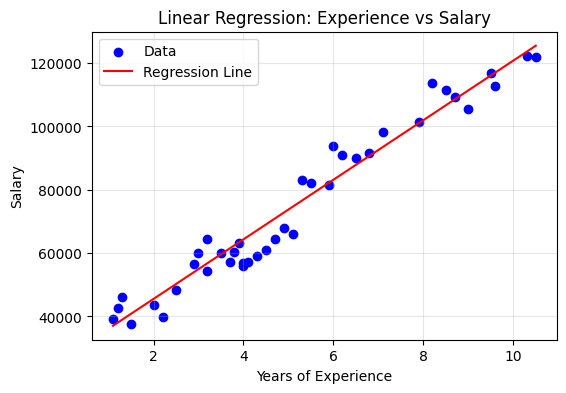

In [47]:
plt.figure(figsize=(6,4))
plt.scatter(X, y, color="blue", label="Data")

x_line = pd.DataFrame({"Experience Years": sorted(X["Experience Years"])})
y_line = model.predict(x_line)

plt.plot(x_line["Experience Years"], y_line, color="red", label="Regression Line")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression: Experience vs Salary")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
